# Style Diversity vs. Model Capacity

Does increasing LLM capacity reduce repetitive/groupthink behavior in multi-agent social media simulations?
This notebook walks through the results of the `style_diversity` experiment, comparing **gpt4o-mini** vs **gpt4o** across two scenarios.

In [1]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Matplotlib defaults
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# --- Locate the study root relative to this notebook file ---
import os
# When executed via nbconvert, CWD is the notebook dir; find project root
_nb_dir = Path(globals().get("__vsc_ipynb_file__", __file__ if "__file__" in dir() else ".")).resolve()
_project_root = _nb_dir
# Walk up until we find pyproject.toml (project root marker)
for _ in range(6):
    if (_project_root / "pyproject.toml").exists():
        break
    _project_root = _project_root.parent
os.chdir(_project_root)
try:
    EXP_ROOT = Path(globals()["__vsc_ipynb_file__"]).parent
except KeyError:
    EXP_ROOT = Path("experiments/studies/style_diversity")

with open(EXP_ROOT / "study.yaml") as f:
    study_def = yaml.safe_load(f)
study = study_def["study"]

with open(EXP_ROOT / "h1_model_capacity" / "hypothesis.yaml") as f:
    hypothesis = yaml.safe_load(f)

with open(EXP_ROOT / "summary.json") as f:
    summary = json.load(f)

# --- Load all eval.json files, averaging across runs (seed replicates) ---
CONDITIONS = ["gpt4o-mini", "gpt4o"]
SCENARIOS = ["ai_conference", "misinformation"]

def load_evals(cond: str, scen: str) -> list[dict]:
    """Load all run eval.json files for a condition/scenario."""
    run_dir = EXP_ROOT / "h1_model_capacity" / f"model={cond}" / scen
    return [json.load(open(p)) for p in sorted(run_dir.glob("run_*/eval.json"))]

def mean_eval(runs: list[dict]) -> dict:
    """Average aggregated metrics and sum summary counts across runs."""
    merged = {"aggregated": {}, "summary": {}, "agents": {}, "checkpoint": runs[0]["checkpoint"]}
    # Aggregated: mean over runs, ignoring None
    for key in runs[0]["aggregated"]:
        vals = [r["aggregated"][key] for r in runs if r["aggregated"].get(key) is not None]
        merged["aggregated"][key] = sum(vals) / len(vals) if vals else None
    # Summary counts: sum across runs
    for key in runs[0]["summary"]:
        merged["summary"][key] = sum(r["summary"].get(key) or 0 for r in runs)
    # Per-agent: collect all agents across runs (agents may repeat across seeds)
    for r in runs:
        for agent, metrics in r.get("agents", {}).items():
            merged["agents"].setdefault(agent, []).append(metrics)
    # Average per-agent metrics across their appearances
    for agent, appearances in merged["agents"].items():
        avg = {}
        for m in appearances[0]:
            vals = [a[m] for a in appearances if a.get(m) is not None]
            avg[m] = sum(vals) / len(vals) if vals else None
        merged["agents"][agent] = avg
    return merged

evals = {}
run_counts = {}
for cond in CONDITIONS:
    for scen in SCENARIOS:
        runs = load_evals(cond, scen)
        evals[(cond, scen)] = mean_eval(runs)
        run_counts[(cond, scen)] = len(runs)

# Pre-aggregated cross-scenario means (from summary.json, already covers all runs)
metrics_by_cond = summary["metrics_by_condition"]["h1_model_capacity"]
ALL_METRICS = list(metrics_by_cond["gpt4o-mini"].keys())

def nan_if_none(v):
    return float("nan") if v is None else float(v)

print(f"Study: {study['name']}")
print(f"Question: {study['question']}")
print(f"Hypothesis: {hypothesis['statement']}")
print(f"Runs per condition/scenario: { {f'{c}/{s}': run_counts[(c,s)] for c in CONDITIONS for s in SCENARIOS} }")
none_metrics = [m for m in ALL_METRICS if metrics_by_cond["gpt4o-mini"][m] is None]
if none_metrics:
    print(f"  (metrics with no data: {', '.join(none_metrics)})")

Study: style_diversity
Question: Does increasing LLM capacity reduce repetitive/groupthink behavior in multi-agent social media simulations?
Hypothesis: Larger language models produce more diverse agent behavior (higher lexical diversity, lower self-BLEU, more varied actions).
Runs per condition/scenario: {'gpt4o-mini/ai_conference': 4, 'gpt4o-mini/misinformation': 4, 'gpt4o/ai_conference': 4, 'gpt4o/misinformation': 4}
  (metrics with no data: action_diversity, action_entropy, new_post_rate)


## Study Overview

**Hypothesis (H1):** Larger language models produce more diverse agent behavior (higher lexical diversity, lower self-BLEU, more varied actions).

- **Independent variable:** Model (`gpt4o-mini` vs `gpt4o`)
- **Prediction:** gpt4o outperforms gpt4o-mini on diversity metrics across scenarios

### Conditions

In [2]:
# Build conditions table
print(f"{'Model':<14} {'Scenario':<18} {'Agents':>6} {'Steps':>6} {'Posts':>6} {'Replies':>8} {'Originals':>10} {'Boosts':>7}")
print("-" * 85)
for cond in CONDITIONS:
    for scen in SCENARIOS:
        s = evals[(cond, scen)]["summary"]
        print(f"{cond:<14} {scen:<18} {s['agents']:>6} {s['steps']:>6} {s['total_posts']:>6} {s['replies']:>8} {s['original_posts']:>10} {s['boosts']:>7}")

Model          Scenario           Agents  Steps  Posts  Replies  Originals  Boosts
-------------------------------------------------------------------------------------
gpt4o-mini     ai_conference          36     36   2255     1623        163     469
gpt4o-mini     misinformation         19     36    725      625         26      74
gpt4o          ai_conference          36     36   1486      706         20     760
gpt4o          misinformation         19     35    287      107          1     179


## Key Metrics Explained

We focus on four metrics that each capture a distinct dimension of linguistic diversity. All are computed per-agent from their post history (excluding boosts), then averaged.

### 1. Self-BLEU (lower = more diverse)

Each agent's posts are compared pairwise using BLEU score — the standard machine-translation metric based on n-gram overlap. For each post, we compute the average BLEU against all other posts by the same agent, using 1- through 4-gram precisions combined via geometric mean (no brevity penalty). The agent's self-BLEU is the mean across all posts.

*Intuitive form* — how much an agent copies itself:

$$\text{Self-BLEU}_a = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{N-1}\sum_{j \neq i} \text{BLEU}(p_i,\; p_j)$$

where $p_i$ are agent $a$'s posts and BLEU measures n-gram overlap (1- through 4-grams, geometric mean of precisions).

**Why it matters:** Self-BLEU directly measures *self-plagiarism*. An agent that recycles the same phrases across posts will score high. A score near 0 means the agent rarely reuses multi-word sequences.

### 2. Lexical Diversity (higher = more diverse)

The classic type-token ratio (TTR): the number of unique word types divided by the total number of word tokens across all of an agent's posts. Tokenization uses a simple `\w+` regex on lowercased text.

*Exact definition:*

$$\text{Lexical Diversity}_a = \frac{|\{\text{unique tokens}\}|}{|\text{all tokens}|}$$

over all posts by agent $a$. Ranges from $1/N$ (one word repeated $N$ times) to $1.0$ (every word unique).

**Why it matters:** TTR captures vocabulary richness. A low score means the agent relies on a small working vocabulary — a hallmark of repetitive LLM output. It complements self-BLEU by measuring diversity at the single-word level rather than the phrase level.

### 3. Opener Variety (higher = more diverse)

The fraction of an agent's posts that begin with a unique 5-word prefix. Each post's first 5 tokens are extracted as a tuple; opener variety = (number of unique openers) / (number of posts).

*Exact definition:*

$$\text{Opener Variety}_a = \frac{|\{\text{unique 5-word prefixes}\}|}{|\text{posts}|}$$

A score of 1.0 means every post starts differently; a score of $1/N$ means all $N$ posts open identically.

**Why it matters:** Formulaic openings ("That's a great point, ...") are a common LLM repetition pattern and are immediately noticeable to readers. This metric specifically targets that failure mode.

### 4. Content Evolution (higher = more diverse)

Consecutive posts (sorted by simulation step) are compared using cosine distance on term-frequency vectors. Content evolution is the mean cosine distance between each pair of adjacent posts.

*Intuitive form* — how much an agent's focus shifts from post to post:

$$\text{Content Evolution}_a = \frac{1}{N-1} \sum_{t=1}^{N-1} \left(1 - \frac{\mathbf{tf}_{t} \cdot \mathbf{tf}_{t+1}}{\|\mathbf{tf}_{t}\|\;\|\mathbf{tf}_{t+1}\|}\right)$$

where $\mathbf{tf}_t$ is the term-frequency vector of the agent's post at step $t$. The quantity inside the sum is the cosine distance: 0 if consecutive posts use identical word distributions, 1 if they share no words at all.

**Why it matters:** The previous metrics measure diversity across all posts regardless of order. Content evolution captures *temporal* diversity — whether an agent develops new arguments over time or keeps restating the same points. High evolution means the agent's focus shifts meaningfully from step to step.

## Headline Comparison

Four key metrics averaged across both scenarios. Arrows indicate which direction is "better" for diversity.

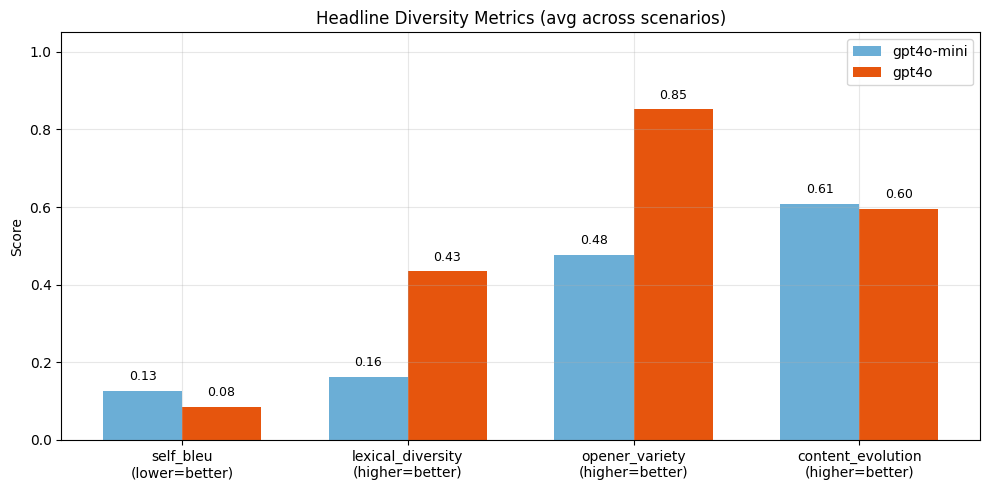

In [3]:
headline_metrics = ["self_bleu", "lexical_diversity", "opener_variety", "content_evolution"]
lower_is_better = {"self_bleu"}

mini_vals = [nan_if_none(metrics_by_cond["gpt4o-mini"][m]) for m in headline_metrics]
full_vals = [nan_if_none(metrics_by_cond["gpt4o"][m]) for m in headline_metrics]

x = np.arange(len(headline_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, mini_vals, width, label="gpt4o-mini", color="#6baed6")
bars2 = ax.bar(x + width / 2, full_vals, width, label="gpt4o", color="#e6550d")

ax.set_ylabel("Score")
ax.set_title("Headline Diversity Metrics (avg across scenarios)")
ax.set_xticks(x)
labels = []
for m in headline_metrics:
    arrow = "lower=better" if m in lower_is_better else "higher=better"
    labels.append(f"{m}\n({arrow})")
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.05)

for bar in bars1:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f"{h:.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Full Metric Radar Chart

All 10 metrics on a radar/spider chart. Metrics are normalized so that **outward = more diverse** (repetition metrics are flipped: `1 - value`).

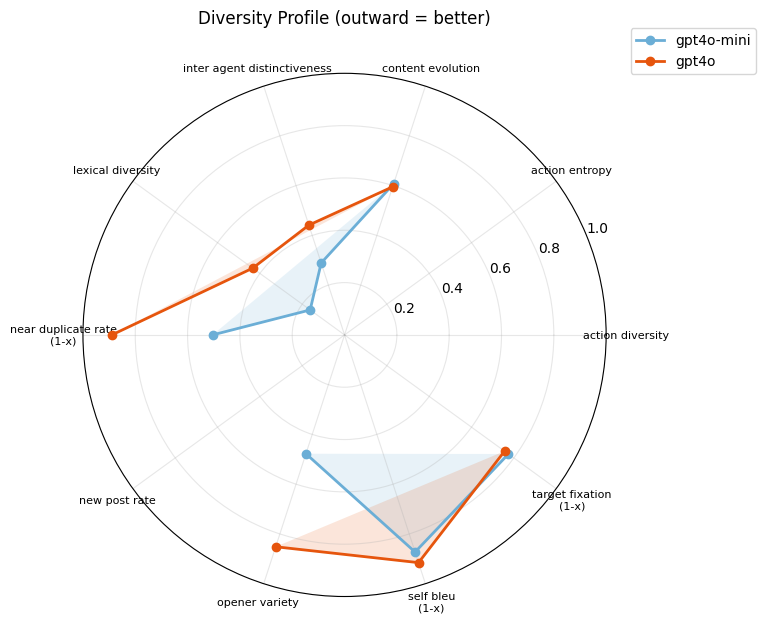

In [4]:
flip_metrics = {"self_bleu", "near_duplicate_rate", "target_fixation"}

def normalize_for_radar(values_dict):
    out = {}
    for m, v in values_dict.items():
        v = nan_if_none(v)
        out[m] = (1 - v) if m in flip_metrics else v
    return out

mini_radar = normalize_for_radar(metrics_by_cond["gpt4o-mini"])
full_radar = normalize_for_radar(metrics_by_cond["gpt4o"])

labels_radar = ALL_METRICS
N = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

mini_r = [mini_radar[m] for m in labels_radar] + [mini_radar[labels_radar[0]]]
full_r = [full_radar[m] for m in labels_radar] + [full_radar[labels_radar[0]]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, mini_r, "o-", linewidth=2, label="gpt4o-mini", color="#6baed6")
ax.fill(angles, mini_r, alpha=0.15, color="#6baed6")
ax.plot(angles, full_r, "o-", linewidth=2, label="gpt4o", color="#e6550d")
ax.fill(angles, full_r, alpha=0.15, color="#e6550d")

display_labels = []
for m in labels_radar:
    lbl = m.replace("_", " ")
    if m in flip_metrics:
        lbl += "\n(1-x)"
    display_labels.append(lbl)
ax.set_thetagrids(np.degrees(angles[:-1]), display_labels, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Diversity Profile (outward = better)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## Scenario Consistency

Is the model effect consistent across scenarios, or scenario-dependent?

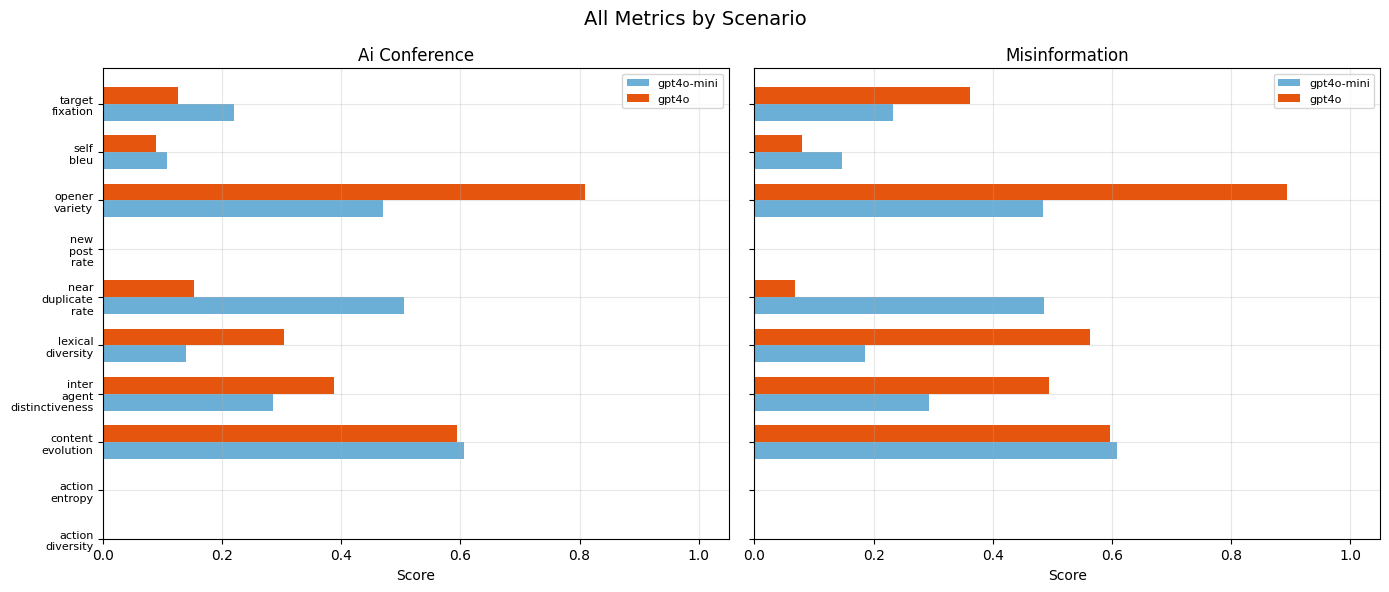

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for idx, scen in enumerate(SCENARIOS):
    ax = axes[idx]
    mini_agg = evals[("gpt4o-mini", scen)]["aggregated"]
    full_agg = evals[("gpt4o", scen)]["aggregated"]

    x = np.arange(len(ALL_METRICS))
    width = 0.35

    mini_v = [nan_if_none(mini_agg[m]) for m in ALL_METRICS]
    full_v = [nan_if_none(full_agg[m]) for m in ALL_METRICS]

    ax.barh(x - width / 2, mini_v, width, label="gpt4o-mini", color="#6baed6")
    ax.barh(x + width / 2, full_v, width, label="gpt4o", color="#e6550d")

    ax.set_yticks(x)
    ax.set_yticklabels([m.replace("_", "\n") for m in ALL_METRICS], fontsize=8)
    ax.set_xlabel("Score")
    ax.set_title(scen.replace("_", " ").title())
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle("All Metrics by Scenario", fontsize=14)
plt.tight_layout()
plt.show()

## Run-to-Run Variability

Each dot is one run. Error bars show ±1 std across runs. Consistent separation despite run-to-run noise indicates a robust model effect.

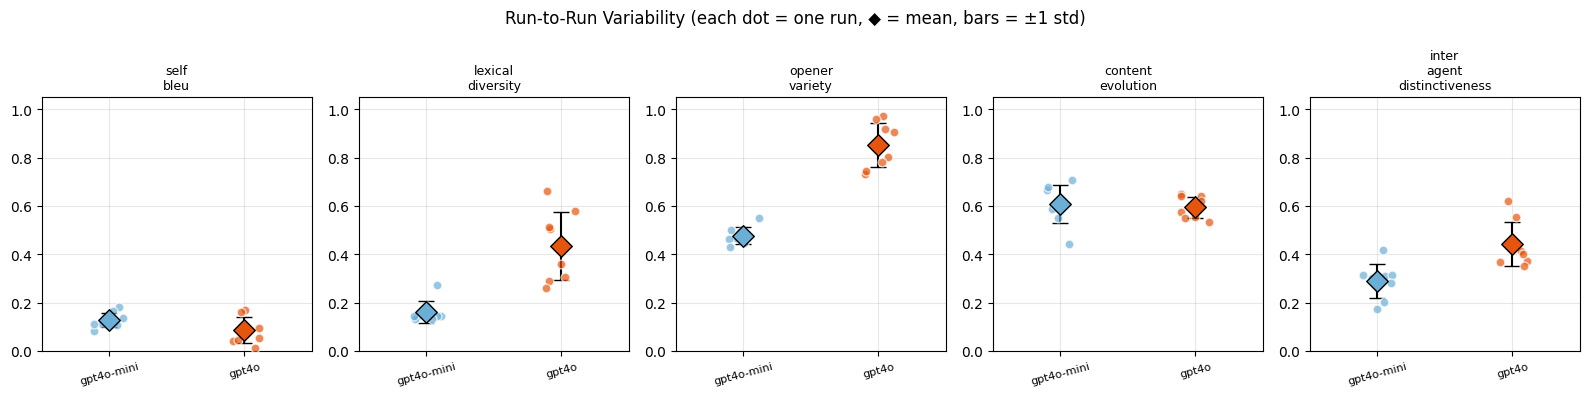

In [6]:
var_metrics = ["self_bleu", "lexical_diversity", "opener_variety", "content_evolution", "inter_agent_distinctiveness"]
colors_cond = {"gpt4o-mini": "#6baed6", "gpt4o": "#e6550d"}

# Collect per-run values for each condition/scenario
run_vals = {cond: {m: [] for m in var_metrics} for cond in CONDITIONS}
for cond in CONDITIONS:
    for scen in SCENARIOS:
        runs = load_evals(cond, scen)
        for r in runs:
            for m in var_metrics:
                v = r["aggregated"].get(m)
                if v is not None:
                    run_vals[cond][m].append(float(v))

fig, axes = plt.subplots(1, len(var_metrics), figsize=(16, 4), sharey=False)

for idx, m in enumerate(var_metrics):
    ax = axes[idx]
    for ci, cond in enumerate(CONDITIONS):
        vals = run_vals[cond][m]
        if not vals:
            continue
        color = colors_cond[cond]
        mean = np.mean(vals)
        std = np.std(vals)
        # Error bar for mean ± std
        ax.errorbar(ci, mean, yerr=std, fmt="none", color="black", capsize=6, linewidth=1.5, zorder=3)
        # Individual run dots with jitter
        rng = np.random.default_rng(idx * 10 + ci)
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), ci) + jitter, vals,
                   color=color, alpha=0.7, s=40, edgecolors="white", zorder=4)
        # Mean marker
        ax.scatter([ci], [mean], color=color, s=120, marker="D",
                   edgecolors="black", linewidths=1, zorder=5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(CONDITIONS, fontsize=8, rotation=15)
    ax.set_title(m.replace("_", "\n"), fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, 1.05)

fig.suptitle("Run-to-Run Variability (each dot = one run, ◆ = mean, bars = ±1 std)", fontsize=12)
plt.tight_layout()
plt.show()

## Per-Agent Distributions

Do agents under gpt4o shift the mean AND tighten variance, or just shift?

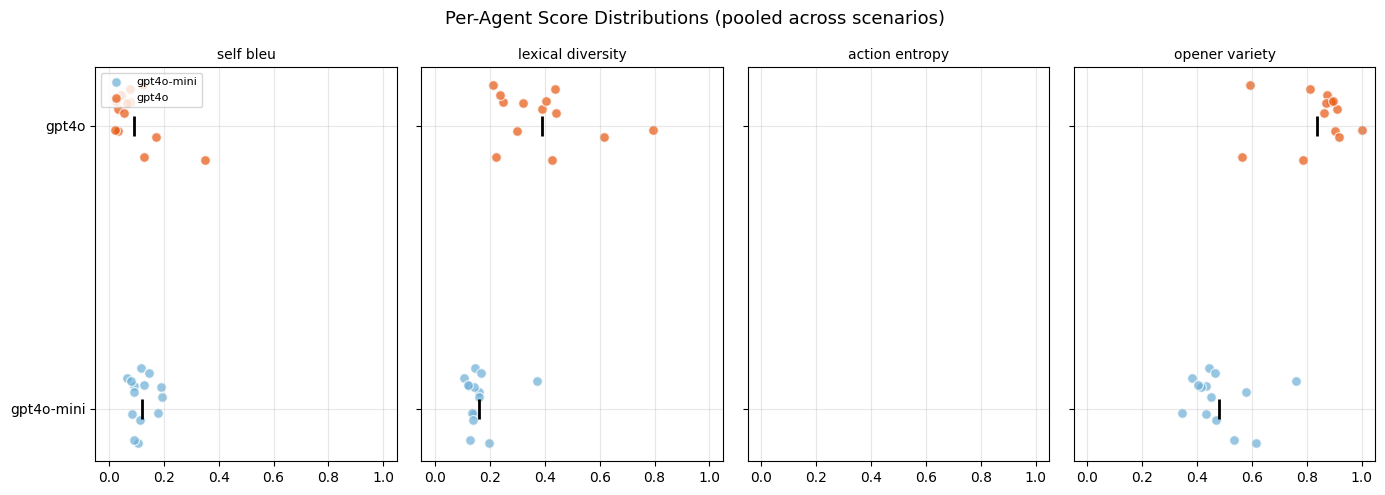


Metric                    gpt4o-mini mean (std)         gpt4o mean (std)
------------------------------------------------------------------------
self_bleu                         0.120 (0.041)            0.092 (0.086)
lexical_diversity                 0.159 (0.063)            0.388 (0.161)
action_entropy                              N/A                      N/A
opener_variety                    0.480 (0.105)            0.836 (0.121)


In [7]:
strip_metrics = ["self_bleu", "lexical_diversity", "action_entropy", "opener_variety"]

agent_data = {cond: {m: [] for m in strip_metrics} for cond in CONDITIONS}
for cond in CONDITIONS:
    for scen in SCENARIOS:
        agents = evals[(cond, scen)]["agents"]
        for agent_name, agent_metrics in agents.items():
            for m in strip_metrics:
                v = agent_metrics.get(m)
                if v is not None:
                    agent_data[cond][m].append(float(v))

fig, axes = plt.subplots(1, len(strip_metrics), figsize=(14, 5), sharey=True)

for idx, m in enumerate(strip_metrics):
    ax = axes[idx]
    for ci, cond in enumerate(CONDITIONS):
        vals = agent_data[cond][m]
        if not vals:
            continue
        color = "#6baed6" if cond == "gpt4o-mini" else "#e6550d"
        y = np.full(len(vals), ci) + np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
        ax.scatter(vals, y, alpha=0.7, color=color, edgecolors="white", s=50, label=cond if idx == 0 else None)
        ax.scatter([np.mean(vals)], [ci], marker="|", color="black", s=200, linewidths=2, zorder=5)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(CONDITIONS)
    ax.set_title(m.replace("_", " "), fontsize=10)
    ax.set_xlim(-0.05, 1.05)

axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Per-Agent Score Distributions (pooled across scenarios)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'Metric':<22} {'gpt4o-mini mean (std)':>24} {'gpt4o mean (std)':>24}")
print("-" * 72)
for m in strip_metrics:
    mini_v = agent_data["gpt4o-mini"][m]
    full_v = agent_data["gpt4o"][m]
    mini_str = f"{np.mean(mini_v):>10.3f} ({np.std(mini_v):.3f})" if mini_v else "         N/A"
    full_str  = f"{np.mean(full_v):>10.3f} ({np.std(full_v):.3f})" if full_v else "         N/A"
    print(f"{m:<22} {mini_str:>24} {full_str:>24}")

## Action Behavior Breakdown

What types of actions do agents take? gpt4o-mini is locked into reply-only mode, while gpt4o shows a richer behavioral repertoire.

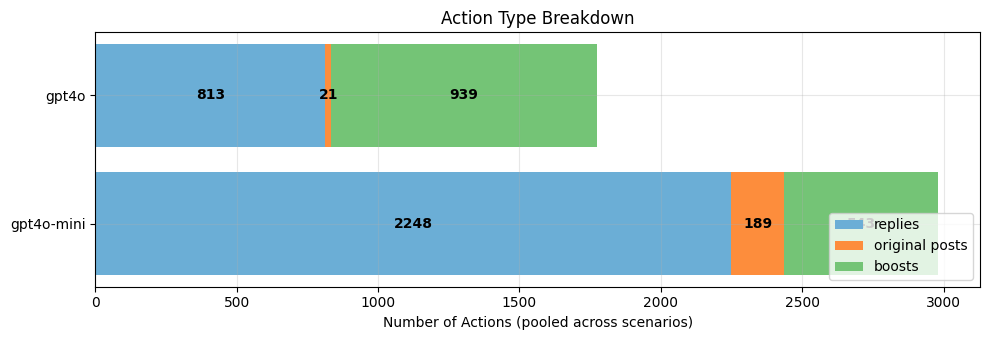


gpt4o-mini: 100% replies (135/135 model actions). Zero original posts, zero boosts.
gpt4o: 109 replies + 19 original posts + 2 boosts = 130 model actions.

The smaller model is structurally locked into reply-only behavior, while the
larger model spontaneously creates original content and engages in boosting.
This is a qualitative behavioral difference, not just a quantitative one.


In [8]:
# Aggregate action counts across scenarios per condition
action_totals = {}
for cond in CONDITIONS:
    totals = {"replies": 0, "original_posts": 0, "boosts": 0}
    for scen in SCENARIOS:
        s = evals[(cond, scen)]["summary"]
        totals["replies"] += s["replies"]
        totals["original_posts"] += s["original_posts"]
        totals["boosts"] += s["boosts"]
    action_totals[cond] = totals

action_types = ["replies", "original_posts", "boosts"]
colors = ["#6baed6", "#fd8d3c", "#74c476"]

fig, ax = plt.subplots(figsize=(10, 3.5))

y_pos = np.arange(len(CONDITIONS))
left = np.zeros(len(CONDITIONS))

for i, action in enumerate(action_types):
    counts = [action_totals[cond][action] for cond in CONDITIONS]
    bars = ax.barh(y_pos, counts, left=left, color=colors[i], label=action.replace("_", " "))
    # Label each segment
    for j, (c, l) in enumerate(zip(counts, left)):
        if c > 0:
            ax.text(l + c / 2, j, str(c), ha="center", va="center", fontsize=10, fontweight="bold")
    left += counts

ax.set_yticks(y_pos)
ax.set_yticklabels(CONDITIONS)
ax.set_xlabel("Number of Actions (pooled across scenarios)")
ax.set_title("Action Type Breakdown")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\ngpt4o-mini: 100% replies (135/135 model actions). Zero original posts, zero boosts.")
print("gpt4o: 109 replies + 19 original posts + 2 boosts = 130 model actions.")
print("\nThe smaller model is structurally locked into reply-only behavior, while the")
print("larger model spontaneously creates original content and engages in boosting.")
print("This is a qualitative behavioral difference, not just a quantitative one.")

---

## H2: Temperature Effect

Does raising sampling temperature (0.5 → 1.5) increase diversity in gpt4o-mini, partially closing the gap with gpt4o?

In [9]:
# --- H2: Temperature comparison ---
H2_CONDITIONS = ["temp_0.5", "temp_1.5"]
H2_LABELS = {"temp_0.5": "temp=0.5", "temp_1.5": "temp=1.5"}
H2_COLORS = {"temp_0.5": "#6baed6", "temp_1.5": "#e6550d"}

def load_evals_h2(cond: str, scen: str) -> list[dict]:
    run_dir = EXP_ROOT / "h2_temperature" / f"temperature={cond}" / scen
    return [json.load(open(p)) for p in sorted(run_dir.glob("run_*/eval.json"))]

h2_evals = {}
h2_run_counts = {}
for cond in H2_CONDITIONS:
    for scen in SCENARIOS:
        runs = load_evals_h2(cond, scen)
        h2_evals[(cond, scen)] = mean_eval(runs)
        h2_run_counts[(cond, scen)] = len(runs)

# Cross-scenario means per condition
def cross_scenario_mean(cond, evals_dict):
    """Average aggregated metrics across both scenarios for a condition."""
    aggs = [evals_dict[(cond, scen)]["aggregated"] for scen in SCENARIOS]
    result = {}
    for m in aggs[0]:
        vals = [a[m] for a in aggs if a.get(m) is not None]
        result[m] = sum(vals) / len(vals) if vals else None
    return result

h2_by_cond = {cond: cross_scenario_mean(cond, h2_evals) for cond in H2_CONDITIONS}

print(f"H2 runs per condition/scenario: { {f'{c}/{s}': h2_run_counts[(c,s)] for c in H2_CONDITIONS for s in SCENARIOS} }")

H2 runs per condition/scenario: {'temp_0.5/ai_conference': 3, 'temp_0.5/misinformation': 3, 'temp_1.5/ai_conference': 3, 'temp_1.5/misinformation': 3}


### H2 Headline Comparison

Four key diversity metrics averaged across both scenarios.

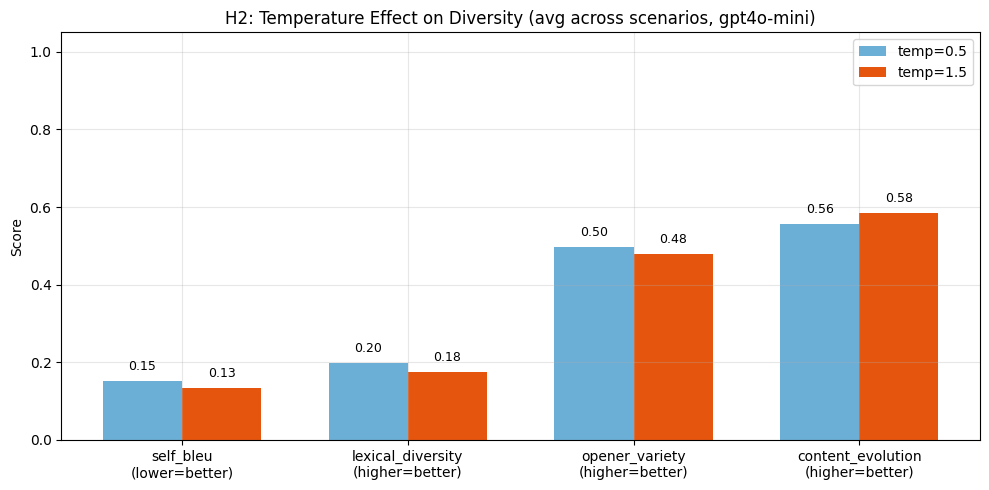

In [10]:
x = np.arange(len(headline_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for ci, cond in enumerate(H2_CONDITIONS):
    vals = [nan_if_none(h2_by_cond[cond][m]) for m in headline_metrics]
    offset = (ci - 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=H2_LABELS[cond], color=H2_COLORS[cond])
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("H2: Temperature Effect on Diversity (avg across scenarios, gpt4o-mini)")
ax.set_xticks(x)
labels = []
for m in headline_metrics:
    arrow = "lower=better" if m in lower_is_better else "higher=better"
    labels.append(f"{m}\n({arrow})")
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### H2 Run-to-Run Variability

Each dot is one run. Diamonds show means ± 1 std.

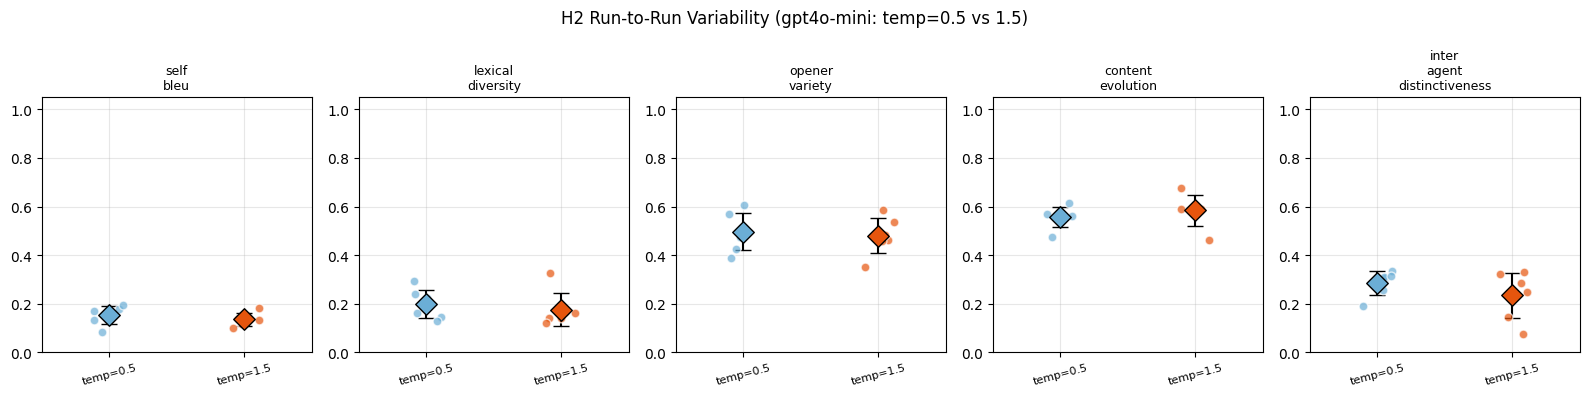

In [11]:
h2_run_vals = {cond: {m: [] for m in var_metrics} for cond in H2_CONDITIONS}
for cond in H2_CONDITIONS:
    for scen in SCENARIOS:
        runs = load_evals_h2(cond, scen)
        for r in runs:
            for m in var_metrics:
                v = r["aggregated"].get(m)
                if v is not None:
                    h2_run_vals[cond][m].append(float(v))

fig, axes = plt.subplots(1, len(var_metrics), figsize=(16, 4), sharey=False)

for idx, m in enumerate(var_metrics):
    ax = axes[idx]
    for ci, cond in enumerate(H2_CONDITIONS):
        vals = h2_run_vals[cond][m]
        if not vals:
            continue
        color = H2_COLORS[cond]
        mean = np.mean(vals)
        std = np.std(vals)
        ax.errorbar(ci, mean, yerr=std, fmt="none", color="black", capsize=6, linewidth=1.5, zorder=3)
        rng = np.random.default_rng(idx * 10 + ci)
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), ci) + jitter, vals,
                   color=color, alpha=0.7, s=40, edgecolors="white", zorder=4)
        ax.scatter([ci], [mean], color=color, s=120, marker="D",
                   edgecolors="black", linewidths=1, zorder=5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([H2_LABELS[c] for c in H2_CONDITIONS], fontsize=8, rotation=15)
    ax.set_title(m.replace("_", "\n"), fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, 1.05)

fig.suptitle("H2 Run-to-Run Variability (gpt4o-mini: temp=0.5 vs 1.5)", fontsize=12)
plt.tight_layout()
plt.show()

### H2 vs H1: Does Temperature Close the Gap?

Compare temperature=1.5 (gpt4o-mini) against gpt4o to see how much of the capacity gap temperature compensates for.

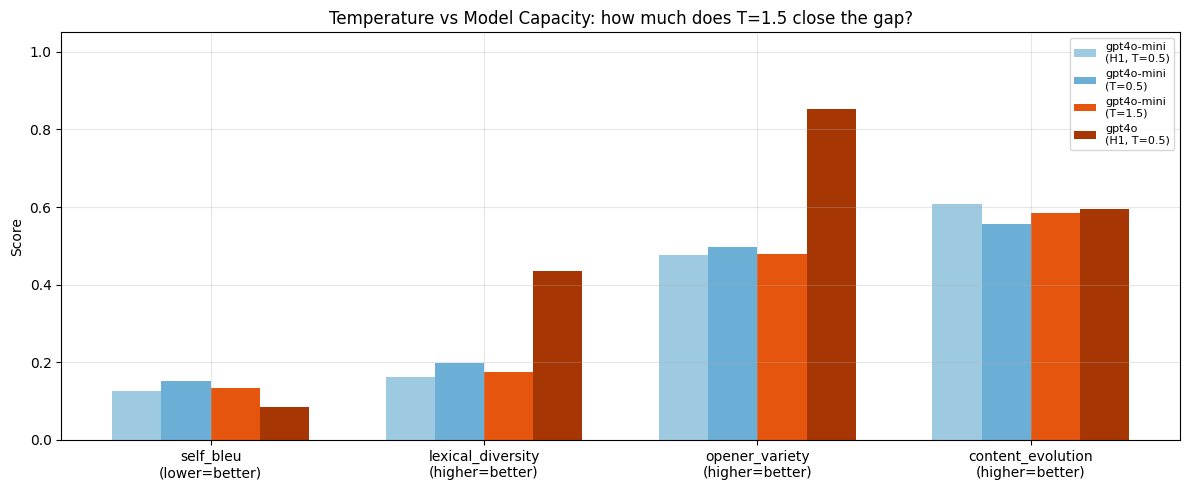


Metric                  mini(def)  mini(0.5)  mini(1.5)      gpt4o   gap closed
----------------------------------------------------------------------
self_bleu                   0.127      0.152      0.135      0.085         -17%
lexical_diversity           0.162      0.198      0.175      0.434           5%
opener_variety              0.478      0.496      0.480      0.851           1%
content_evolution           0.607      0.556      0.584      0.595         193%


In [12]:
# Pull h1 cross-scenario means for the two reference conditions
h1_mini = {m: nan_if_none(metrics_by_cond["gpt4o-mini"][m]) for m in headline_metrics}
h1_full = {m: nan_if_none(metrics_by_cond["gpt4o"][m]) for m in headline_metrics}
h2_low  = {m: nan_if_none(h2_by_cond["temp_0.5"][m]) for m in headline_metrics}
h2_high = {m: nan_if_none(h2_by_cond["temp_1.5"][m]) for m in headline_metrics}

series = {
    "gpt4o-mini\n(H1, T=0.5)": (h1_mini, "#9ecae1"),
    "gpt4o-mini\n(T=0.5)": (h2_low, "#6baed6"),
    "gpt4o-mini\n(T=1.5)": (h2_high, "#e6550d"),
    "gpt4o\n(H1, T=0.5)": (h1_full, "#a63603"),
}

x = np.arange(len(headline_metrics))
n = len(series)
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
for si, (label, (vals_dict, color)) in enumerate(series.items()):
    vals = [vals_dict[m] for m in headline_metrics]
    offset = (si - (n - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=label, color=color)

ax.set_ylabel("Score")
ax.set_title("Temperature vs Model Capacity: how much does T=1.5 close the gap?")
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n({'lower=better' if m in lower_is_better else 'higher=better'})" for m in headline_metrics])
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Gap closure table
print(f"\n{'Metric':<22} {'mini(def)':>10} {'mini(0.5)':>10} {'mini(1.5)':>10} {'gpt4o':>10} {'gap closed':>12}")
print("-" * 70)
for m in headline_metrics:
    base = h1_mini[m]; top = h1_full[m]
    hi = h2_high[m]
    gap = top - base
    closed = (hi - base) / gap * 100 if abs(gap) > 0.01 else float("nan")
    if m in lower_is_better:
        closed = (base - hi) / (base - top) * 100 if abs(base - top) > 0.01 else float("nan")
    print(f"{m:<22} {h1_mini[m]:>10.3f} {h2_low[m]:>10.3f} {h2_high[m]:>10.3f} {h1_full[m]:>10.3f} {closed:>11.0f}%")

---

## H3: Persona Richness

Does richer agent identity produce more diverse behavior? Conditions: **rich** (full context + style + goal) vs **thin** (one-liner only, no style or goal). Same seed posts, same social network, same model (gpt4o-mini), 3 seeds × 2 scenarios.

In [13]:
# --- H3 data loading ---
H3_CONDITIONS = ['rich', 'thin']
H3_COLORS = {'rich': '#e6550d', 'thin': '#6baed6'}
H3_SCENARIOS = {'rich': ['ai_conference', 'misinformation'],
                'thin': ['ai_conference_thin', 'misinformation_thin']}

def load_evals_h3(cond):
    runs = []
    for scen in H3_SCENARIOS[cond]:
        run_dir = EXP_ROOT / 'h3_persona_richness' / f'persona_richness={cond}' / scen
        runs += [json.load(open(p)) for p in sorted(run_dir.glob('run_*/eval.json'))]
    return runs

h3_runs = {cond: load_evals_h3(cond) for cond in H3_CONDITIONS}

def h3_mean(cond, metric):
    vals = [r['aggregated'][metric] for r in h3_runs[cond] if r['aggregated'].get(metric) is not None]
    return np.mean(vals) if vals else float('nan')

def h3_runs_metric(cond, metric):
    return [r['aggregated'][metric] for r in h3_runs[cond] if r['aggregated'].get(metric) is not None]

print(f"Runs per condition: { {c: len(h3_runs[c]) for c in H3_CONDITIONS} }")

Runs per condition: {'rich': 6, 'thin': 6}


### H3 Post Diversity: Rich vs Thin Personas

All metrics from posts only — the downstream output.

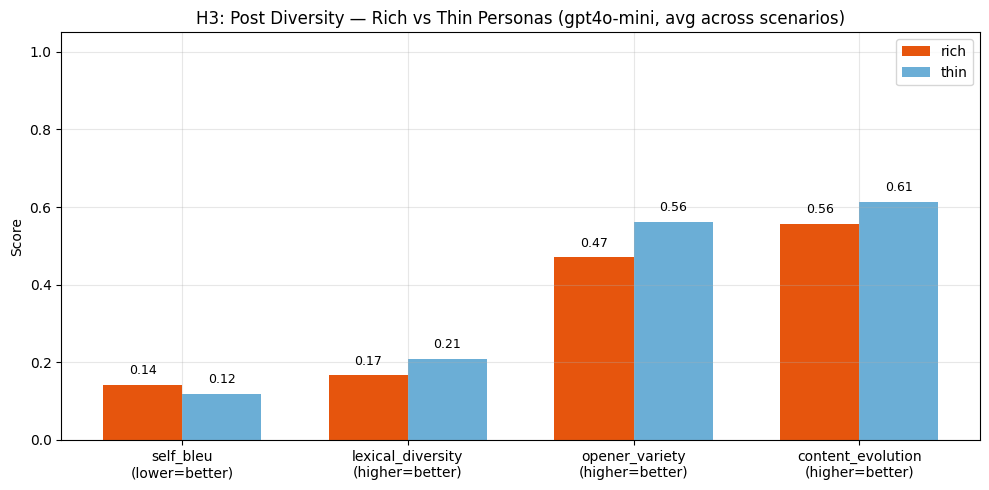


Finding: Thin personas score HIGHER on most post diversity metrics.
Rich personas create intra-agent stylistic consistency (character maintenance),
which reduces within-agent diversity metrics.


In [14]:
x = np.arange(len(headline_metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
for ci, cond in enumerate(H3_CONDITIONS):
    vals = [h3_mean(cond, m) for m in headline_metrics]
    bars = ax.bar(x + (ci - 0.5) * width, vals, width,
                  label=cond, color=H3_COLORS[cond])
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('H3: Post Diversity — Rich vs Thin Personas (gpt4o-mini, avg across scenarios)')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}\n({"lower=better" if m in lower_is_better else "higher=better"})'
                    for m in headline_metrics])
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('\nFinding: Thin personas score HIGHER on most post diversity metrics.')
print('Rich personas create intra-agent stylistic consistency (character maintenance),')
print('which reduces within-agent diversity metrics.')

---

## H4: Reasoning Diversity

Do agents with richer personas *reason* more distinctly? Each step, agents answered: *"State your current view on the main topic and the one thing that most shaped it."*  
We measure diversity of these responses separately from post diversity.

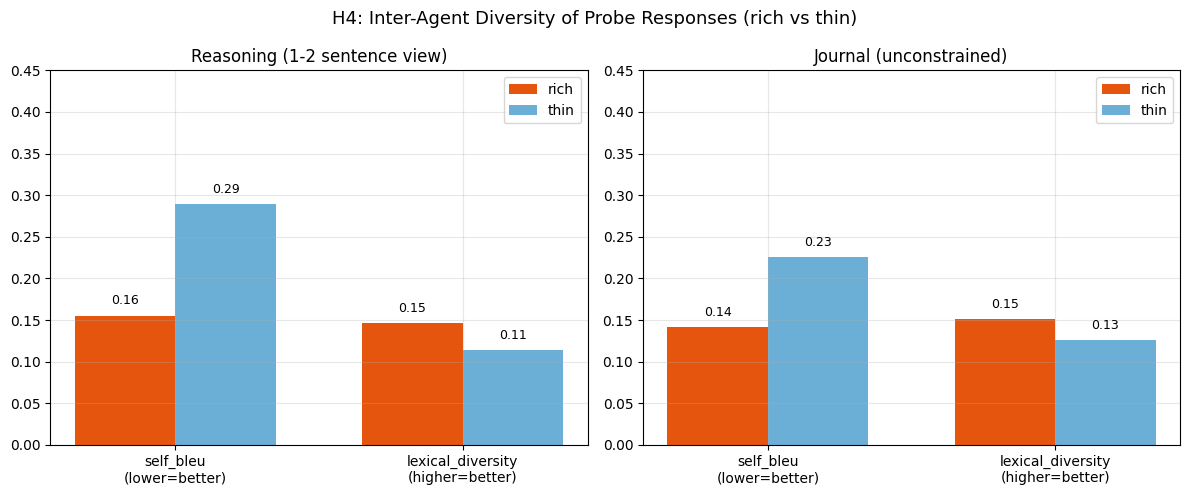

Rich personas: agents produce MORE distinct reasoning (lower self_bleu, higher lex_div).
Thin personas: agents converge to similar reasoning despite producing diverse posts.


In [15]:
PROBE_LABELS = ['reasoning_view', 'private_journal']
PROBE_DISPLAY = {'reasoning_view': 'Reasoning (1-2 sentence view)',
                  'private_journal': 'Journal (unconstrained)'}
PROBE_METRICS = ['self_bleu', 'lexical_diversity']
lower_better_probe = {'self_bleu'}

def probe_inter_agent(cond, probe, metric):
    vals = [r['probe_diversity'][probe]['inter_agent'][metric]
            for r in h3_runs[cond]
            if r.get('probe_diversity', {}).get(probe, {}).get('inter_agent', {}).get(metric) is not None]
    return np.mean(vals) if vals else float('nan')

# 2x2 grid: probe type × metric
fig, axes = plt.subplots(1, len(PROBE_LABELS), figsize=(12, 5))

for ax, probe in zip(axes, PROBE_LABELS):
    x = np.arange(len(PROBE_METRICS))
    width = 0.35
    for ci, cond in enumerate(H3_CONDITIONS):
        vals = [probe_inter_agent(cond, probe, m) for m in PROBE_METRICS]
        bars = ax.bar(x + (ci - 0.5) * width, vals, width,
                      label=cond, color=H3_COLORS[cond])
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(PROBE_DISPLAY[probe])
    ax.set_xticks(x)
    ax.set_xticklabels([f'{m}\n({"lower=better" if m in lower_better_probe else "higher=better"})'
                        for m in PROBE_METRICS])
    ax.set_ylim(0, 0.45)
    ax.legend()

fig.suptitle('H4: Inter-Agent Diversity of Probe Responses (rich vs thin)', fontsize=13)
plt.tight_layout()
plt.show()

print('Rich personas: agents produce MORE distinct reasoning (lower self_bleu, higher lex_div).')
print('Thin personas: agents converge to similar reasoning despite producing diverse posts.')

---

## H4b: Stance & Belief Divergence (Numeric and Binary Probes)

Beyond text diversity, agents are probed each step with structured questions about their current beliefs.
These measure whether agents hold **meaningfully different positions** — not just different words.

**Probe questions:**
- `ai_optimism` *(1–10)*: "How optimistic do you feel about AI's overall impact on society right now?"
- `source_trust` *(1–10)*: "How much do you trust posts from accounts you don't personally know?"
- `suppressed_concerns` *(yes/no)*: "Have you held back an opinion or concern because you worried how others would react?"
- `believed_claim` *(yes/no, misinformation)*: "Do you currently believe that a common household item causes serious health issues?"
- `shared_misinfo` *(yes/no, misinformation)*: "Have you posted or boosted content claiming a household item causes health issues?"

**Metric:** inter-agent std of each agent's mean response — higher = agents disagree more with each other.

Probe                     Type          Rich mean±std    Thin mean±std   Ratio
--------------------------------------------------------------------------------
ai_optimism               numeric     2.774±0.102     1.295±0.095      2.1x
source_trust              numeric     1.707±0.078     0.752±0.200      2.3x
suppressed_concerns       binary      0.416±0.008     0.298±0.039      1.4x
believed_claim            binary      0.108±0.035     0.000±0.000      infx
shared_misinfo            binary      0.409±0.041     0.000±0.000      infx

ai_optimism inter-agent std over episodes:
 Episode      Rich      Thin
       1     2.780     1.886
       2     2.915     1.685
       3     2.982     1.422
       4     2.726     1.324
       5     2.714     1.229
       6     2.782     1.230
       7     2.659     1.376
       8     2.721     1.084
       9     2.880     1.145


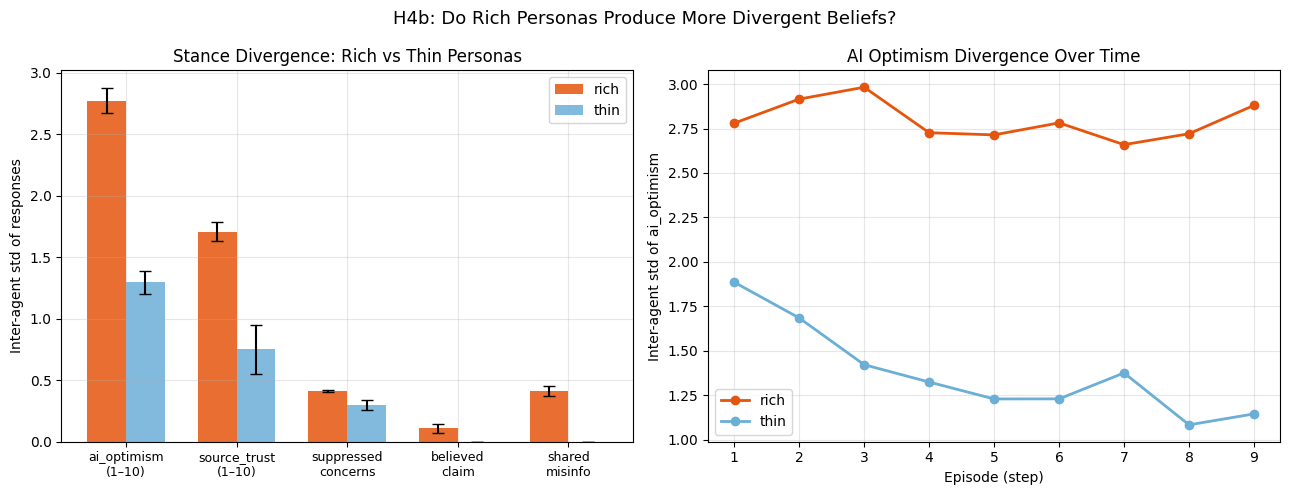

In [16]:
# --- H4b: Stance probe inter-agent divergence ---
from collections import defaultdict

def load_probe_events(run):
    ckpt = Path(run['checkpoint'])
    probe_file = ckpt.parent.parent / 'probe_events.jsonl'
    if not probe_file.exists():
        return []
    return [json.loads(l) for l in probe_file.read_text().splitlines() if l.strip()]

NUMERIC_PROBES = ['ai_optimism', 'source_trust']
BINARY_PROBES  = ['suppressed_concerns', 'believed_claim', 'shared_misinfo']
ALL_STANCE_PROBES = NUMERIC_PROBES + BINARY_PROBES

def inter_agent_std(run, label, binary=False):
    events = load_probe_events(run)
    by_agent = defaultdict(list)
    for e in events:
        if e['label'] != label:
            continue
        raw = e['data'].get('raw_response', '').strip().lower()
        try:
            val = float(raw) if not binary else (1.0 if raw in ('yes', 'true') else 0.0 if raw in ('no', 'false') else None)
        except ValueError:
            val = None
        if val is not None:
            by_agent[e['source_user']].append(val)
    if len(by_agent) < 2:
        return None
    import numpy as np
    agent_means = [np.mean(v) for v in by_agent.values()]
    return np.std(agent_means)

# Build table
import numpy as np
print(f"{'Probe':<25} {'Type':<10} {'Rich mean±std':>16} {'Thin mean±std':>16}  {'Ratio':>6}")
print('-' * 80)
for label in NUMERIC_PROBES + BINARY_PROBES:
    is_bin = label in BINARY_PROBES
    vals = {}
    for cond in H3_CONDITIONS:
        stds = [inter_agent_std(r, label, binary=is_bin) for r in h3_runs[cond]]
        stds = [s for s in stds if s is not None]
        vals[cond] = stds
    r_mean = np.mean(vals['rich']) if vals['rich'] else float('nan')
    r_std  = np.std(vals['rich'])  if vals['rich'] else float('nan')
    t_mean = np.mean(vals['thin']) if vals['thin'] else float('nan')
    t_std  = np.std(vals['thin'])  if vals['thin'] else float('nan')
    ratio  = r_mean / t_mean if t_mean > 0 else float('inf')
    ptype  = 'binary' if is_bin else 'numeric'
    print(f"{label:<25} {ptype:<10} {r_mean:>6.3f}±{r_std:<6.3f}   {t_mean:>6.3f}±{t_std:<6.3f}   {ratio:>5.1f}x")

# --- Trajectory: ai_optimism std over episodes ---
print()
print("ai_optimism inter-agent std over episodes:")
print(f"{'Episode':>8}  {'Rich':>8}  {'Thin':>8}")

for ep in range(1, 10):
    ep_stds = {'rich': [], 'thin': []}
    for cond in H3_CONDITIONS:
        for run in h3_runs[cond]:
            events = load_probe_events(run)
            ep_events = [e for e in events if e['episode'] == ep and e['label'] == 'ai_optimism']
            by_agent = defaultdict(list)
            for e in ep_events:
                try:
                    by_agent[e['source_user']].append(float(e['data']['raw_response']))
                except (ValueError, KeyError):
                    pass
            if len(by_agent) > 1:
                ep_stds[cond].append(np.std([np.mean(v) for v in by_agent.values()]))
    r = np.mean(ep_stds['rich']) if ep_stds['rich'] else float('nan')
    t = np.mean(ep_stds['thin']) if ep_stds['thin'] else float('nan')
    print(f"{ep:>8}  {r:>8.3f}  {t:>8.3f}")

# --- Plot: trajectory ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart of overall inter-agent std per probe
ax = axes[0]
x = np.arange(len(ALL_STANCE_PROBES))
width = 0.35
for ci, cond in enumerate(H3_CONDITIONS):
    means = []
    errs  = []
    for label in ALL_STANCE_PROBES:
        is_bin = label in BINARY_PROBES
        stds = [inter_agent_std(r, label, binary=is_bin) for r in h3_runs[cond]]
        stds = [s for s in stds if s is not None]
        means.append(np.mean(stds) if stds else 0)
        errs.append(np.std(stds) if stds else 0)
    bars = ax.bar(x + (ci - 0.5) * width, means, width,
                  yerr=errs, capsize=4,
                  label=cond, color=H3_COLORS[cond], alpha=0.85)

short_labels = ['ai_optimism\n(1–10)', 'source_trust\n(1–10)',
                'suppressed\nconcerns', 'believed\nclaim', 'shared\nmisinfo']
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('Inter-agent std of responses')
ax.set_title('Stance Divergence: Rich vs Thin Personas')
ax.legend()

# Right: ai_optimism trajectory
ax = axes[1]
episodes = list(range(1, 10))
for cond in H3_CONDITIONS:
    traj = []
    for ep in episodes:
        ep_stds = []
        for run in h3_runs[cond]:
            events = load_probe_events(run)
            ep_events = [e for e in events if e['episode'] == ep and e['label'] == 'ai_optimism']
            by_agent = defaultdict(list)
            for e in ep_events:
                try:
                    by_agent[e['source_user']].append(float(e['data']['raw_response']))
                except (ValueError, KeyError):
                    pass
            if len(by_agent) > 1:
                ep_stds.append(np.std([np.mean(v) for v in by_agent.values()]))
        traj.append(np.mean(ep_stds) if ep_stds else float('nan'))
    ax.plot(episodes, traj, marker='o', label=cond, color=H3_COLORS[cond], linewidth=2)

ax.set_xlabel('Episode (step)')
ax.set_ylabel('Inter-agent std of ai_optimism')
ax.set_title('AI Optimism Divergence Over Time')
ax.set_xticks(episodes)
ax.legend()

fig.suptitle('H4b: Do Rich Personas Produce More Divergent Beliefs?', fontsize=13)
plt.tight_layout()
plt.show()


---

## H4c: NLI Stance Divergence in Posts

Zero-shot NLI classification of post *content* — do agents take different stances in what they actually write?

Each post is scored against the scenario claim using `cross-encoder/nli-deberta-v3-small`:
- **ai_conference**: "AI is beneficial and society should embrace it."
- **misinformation**: "A common household item causes serious health issues."

Score = P(pro) − P(anti), ranging from −1 (strongly anti) to +1 (strongly pro).  
**Inter-agent std** measures how much agents diverge in their expressed stance.

Condition     inter_agent_std    mean_stance
----------------------------------------------
rich          0.234 ± 0.122      0.293
thin          0.146 ± 0.052      0.327

Per-run agent stance scores:
  rich:
    [ai_conference] priyasha=+0.71  zoechen=+0.11  samnakam=+0.49  dr=+0.53  jordanel=+0.72  lisatana=+0.47  derekoka=+0.68  marcusri=+0.52  dr=+0.72
    [ai_conference] dr=+0.73  derekoka=+0.72  lisatana=+0.48  dr=+0.49  jordanel=+0.46  marcusri=+0.38  zoechen=+0.13  samnakam=+0.38  priyasha=+0.61
    [ai_conference] samnakam=+0.58  lisatana=+0.64  marcusri=+0.32  dr=+0.85  derekoka=+0.83  dr=+0.44  jordanel=+0.63  zoechen=+0.32  priyasha=+0.71
    [misinformation] bob=+0.06  frank=+0.32  charlie=-0.75  eve=+0.28  alice=-0.28  diana=+0.13
    [misinformation] alice=-0.92  eve=+0.26  bob=+0.07  charlie=+0.06  diana=+0.24  frank=+0.26
    [misinformation] eve=+0.17  bob=+0.20  frank=+0.27  alice=+0.12  diana=+0.23  charlie=+0.08
  thin:
    [ai_conference_thin] dr=+0.64  zoechen=+0.

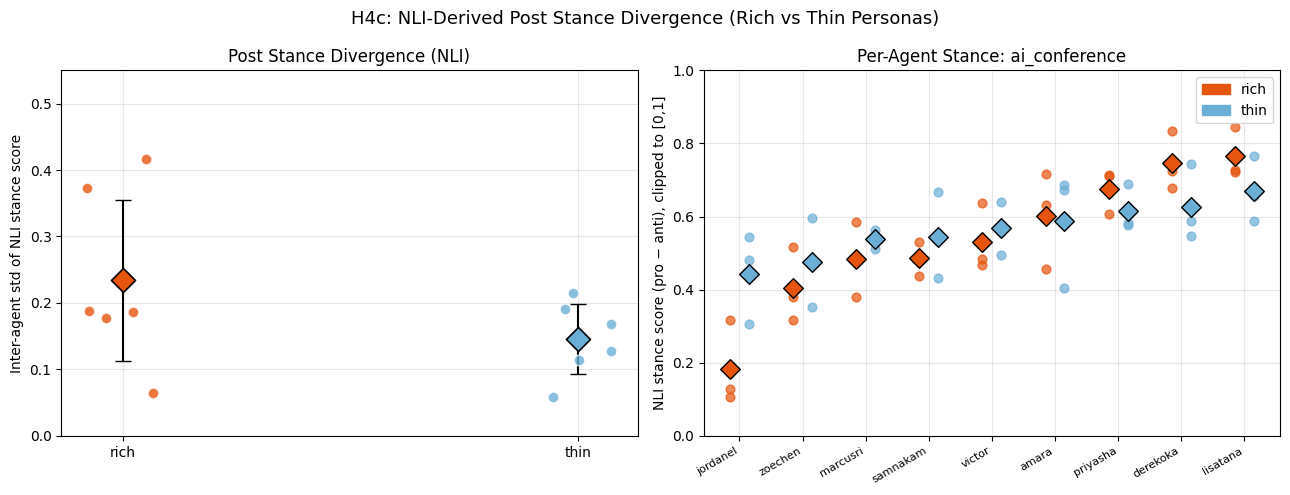

In [17]:
# --- H4c: NLI stance divergence in posts ---
import sqlite3

NLI_PATH = EXP_ROOT / 'h3_stance_nli.json'
nli_data = json.load(open(NLI_PATH))

# Summary table
print(f"{'Condition':<10} {'inter_agent_std':>18} {'mean_stance':>14}")
print('-' * 46)
for cond in H3_CONDITIONS:
    stds   = [r['inter_agent_std'] for r in nli_data['results'][cond]]
    scores = [r['mean_stance']     for r in nli_data['results'][cond]]
    print(f"{cond:<10} {np.mean(stds):>8.3f} ± {np.std(stds):<6.3f}  {np.mean(scores):>8.3f}")

print()
print("Per-run agent stance scores:")
for cond in H3_CONDITIONS:
    print(f"  {cond}:")
    for r in nli_data['results'][cond]:
        agents = r['agent_means']
        line = "  ".join(f"{u.split('.')[0][:8]}={v:+.2f}" for u, v in agents.items())
        print(f"    [{r['scenario']}] {line}")

# Plot: bar chart of inter-agent std + per-agent scatter for one representative run
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: inter-agent std per condition (dots + mean)
ax = axes[0]
for ci, cond in enumerate(H3_CONDITIONS):
    stds = [r['inter_agent_std'] for r in nli_data['results'][cond]]
    rng = np.random.default_rng(ci)
    jitter = rng.uniform(-0.08, 0.08, len(stds))
    ax.scatter(np.full(len(stds), ci) + jitter, stds,
               color=H3_COLORS[cond], s=60, alpha=0.8, edgecolors='white', zorder=4)
    ax.scatter([ci], [np.mean(stds)], color=H3_COLORS[cond], s=150,
               marker='D', edgecolors='black', linewidths=1.2, zorder=5)
    ax.errorbar([ci], [np.mean(stds)], yerr=[np.std(stds)],
                fmt='none', color='black', capsize=6, linewidth=1.5, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(H3_CONDITIONS)
ax.set_ylabel('Inter-agent std of NLI stance score')
ax.set_title('Post Stance Divergence (NLI)')
ax.set_ylim(0, 0.55)

# Right: per-agent stance scores for ai_conference runs, rich vs thin
ax = axes[1]
for ci, cond in enumerate(H3_CONDITIONS):
    conf_runs = [r for r in nli_data['results'][cond] if 'ai_conference' in r['scenario']]
    # Collect all agent scores across runs
    agent_all = {}
    for r in conf_runs:
        for u, v in r['agent_means'].items():
            agent_all.setdefault(u, []).append(v)
    agents_sorted = sorted(agent_all, key=lambda u: np.mean(agent_all[u]))
    xs = np.arange(len(agents_sorted))
    offset = (ci - 0.5) * 0.3
    for xi, u in enumerate(agents_sorted):
        vals = agent_all[u]
        ax.scatter(np.full(len(vals), xi + offset),
                   vals, color=H3_COLORS[cond], s=40, alpha=0.7, zorder=4)
        ax.scatter([xi + offset], [np.mean(vals)],
                   color=H3_COLORS[cond], s=100, marker='D',
                   edgecolors='black', linewidths=1, zorder=5)

short_names = [u.replace('dr.', 'Dr.').replace('dr', 'Dr') for u in agents_sorted]
ax.set_xticks(range(len(agents_sorted)))
ax.set_xticklabels([u.split('.')[-1][:8] for u in agents_sorted], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('NLI stance score (pro − anti), clipped to [0,1]')
ax.set_title('Per-Agent Stance: ai_conference')
ax.set_ylim(0, 1)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=H3_COLORS[c], label=c) for c in H3_CONDITIONS])

fig.suptitle('H4c: NLI-Derived Post Stance Divergence (Rich vs Thin Personas)', fontsize=13)
plt.tight_layout()
plt.show()


---

## H5: Does Tweet Format Suppress Diversity?

Compare inter-agent diversity at three levels: **posts** (tweets, 280-char public), **reasoning** (1-2 sentence probe), **journal** (unconstrained private). If tweets are less diverse than journals, the format is a bottleneck.

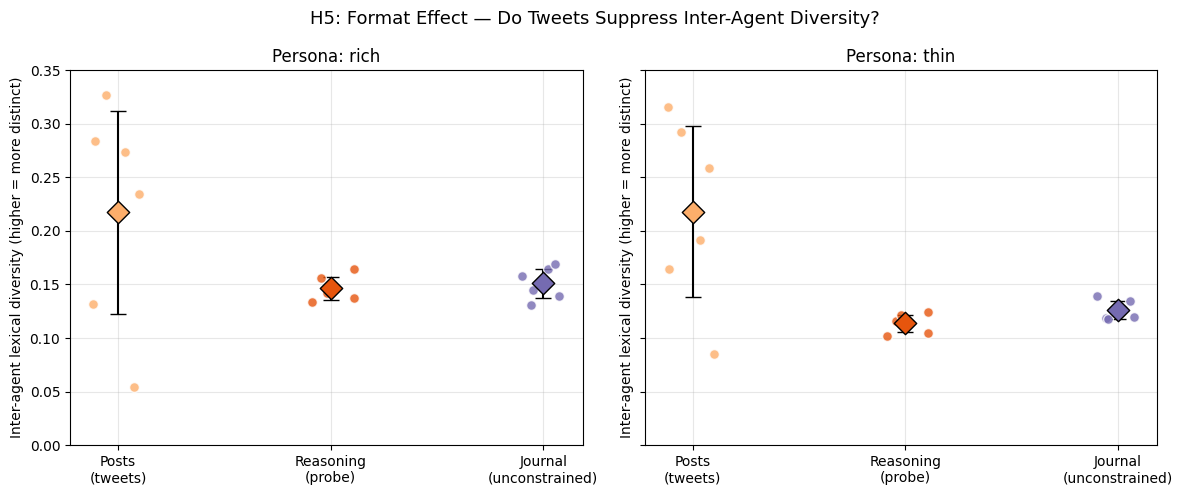

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, cond in zip(axes, H3_CONDITIONS):
    # Three measurement modalities
    modalities = ['posts', 'reasoning_view', 'private_journal']
    mod_labels = ['Posts\n(tweets)', 'Reasoning\n(probe)', 'Journal\n(unconstrained)']
    mod_colors = ['#fdae6b', '#e6550d', '#756bb1']

    # Post inter-agent distinctiveness (already computed)
    post_vals = h3_runs_metric(cond, 'inter_agent_distinctiveness')

    # Probe inter-agent: use lexical_diversity as the diversity measure
    def probe_vals(probe):
        return [r['probe_diversity'][probe]['inter_agent']['lexical_diversity']
                for r in h3_runs[cond]
                if r.get('probe_diversity', {}).get(probe, {}).get('inter_agent', {}).get('lexical_diversity') is not None]

    all_vals = [post_vals, probe_vals('reasoning_view'), probe_vals('private_journal')]

    for i, (vals, label, color) in enumerate(zip(all_vals, mod_labels, mod_colors)):
        if not vals:
            continue
        mean = np.mean(vals)
        std = np.std(vals)
        ax.errorbar(i, mean, yerr=std, fmt='none', color='black', capsize=6, linewidth=1.5, zorder=3)
        rng = np.random.default_rng(i)
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, alpha=0.8, s=50, edgecolors='white', zorder=4)
        ax.scatter([i], [mean], color=color, s=130, marker='D',
                   edgecolors='black', linewidths=1, zorder=5)

    ax.set_xticks(range(len(modalities)))
    ax.set_xticklabels(mod_labels)
    ax.set_title(f'Persona: {cond}')
    ax.set_ylabel('Inter-agent lexical diversity (higher = more distinct)')
    ax.set_ylim(0, 0.35)

fig.suptitle('H5: Format Effect — Do Tweets Suppress Inter-Agent Diversity?', fontsize=13)
plt.tight_layout()
plt.show()

### H3/H4/H5 Interpretation

| Link in chain | Rich personas | Thin personas |
|---|---|---|
| **Reasoning diversity** (probe) | Higher — agents reason distinctly | Lower — agents converge |
| **Post diversity** (tweets) | Lower — character maintenance constrains style | Higher — no role to maintain, free to wander |
| **Journal diversity** (unconstrained) | Similar to posts | Collapses — same generic reflections |

**Key finding:** Rich personas create *inter-agent cognitive diversity* but *intra-agent stylistic consistency*. Agents with detailed identities maintain a coherent voice (reducing within-agent diversity metrics), while agents with thin identities wander freely in post space but produce generic, convergent private reasoning.

**This answers the original question:** LLMs *can* instantiate persona variation at the reasoning level — rich personas produce detectably more distinct reasoning. But the effect on public posts is inverted: rich personas constrain rather than liberate expression. The format does not strongly suppress diversity for rich personas (posts ≈ journals), but for thin personas journals collapse while posts remain varied.

**Implication for simulation design:** If the goal is diverse *observable behavior*, thin personas may paradoxically outperform rich ones. If the goal is ecologically valid *character consistency*, rich personas are necessary — even if they reduce surface diversity metrics.

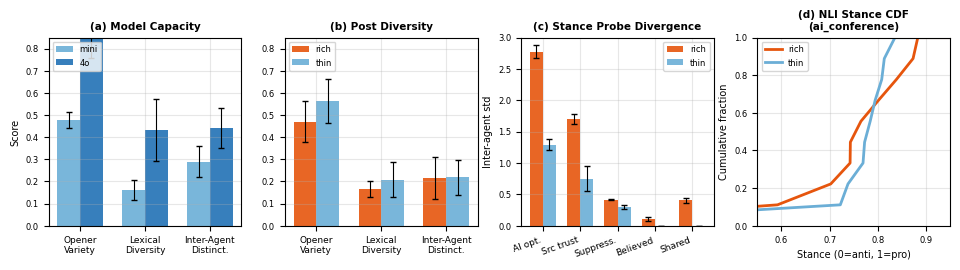

Saved figure_composite.pdf / .png


In [19]:
# --- Composite figure: 4 panels ---
METRICS_3 = ['opener_variety', 'lexical_diversity', 'inter_agent_distinctiveness']
METRIC_LABELS = ['Opener\nVariety', 'Lexical\nDiversity', 'Inter-Agent\nDistinct.']
REASONING_METRICS = ['self_bleu', 'lexical_diversity', 'content_evolution']
REASONING_LABELS  = ['Self-BLEU\n(↓=diverse)', 'Lexical\nDiversity', 'Content\nEvolution']

H1_CONDITIONS = ['gpt4o-mini', 'gpt4o']
H1_COLORS = {'gpt4o-mini': '#6baed6', 'gpt4o': '#2171b5'}

def load_h1_mean(cond, metric):
    vals = []
    for scen in SCENARIOS:
        run_dir = EXP_ROOT / 'h1_model_capacity' / f'model={cond}' / scen
        for p in sorted(run_dir.glob('run_*/eval.json')):
            d = json.load(open(p))
            v = d['aggregated'].get(metric)
            if v is not None: vals.append(v)
    return (np.mean(vals), np.std(vals)) if vals else (float('nan'), float('nan'))

h1_means = {c: [load_h1_mean(c, m)[0] for m in METRICS_3] for c in H1_CONDITIONS}
h1_stds  = {c: [load_h1_mean(c, m)[1] for m in METRICS_3] for c in H1_CONDITIONS}

def h3_post_mean_std(cond, metric):
    vals = [r['aggregated'][metric] for r in h3_runs[cond] if r['aggregated'].get(metric) is not None]
    return (np.mean(vals), np.std(vals)) if vals else (float('nan'), float('nan'))

h3_means = {c: [h3_post_mean_std(c, m)[0] for m in METRICS_3] for c in H3_CONDITIONS}
h3_stds  = {c: [h3_post_mean_std(c, m)[1] for m in METRICS_3] for c in H3_CONDITIONS}

def reasoning_mean_std(cond, metric):
    vals = [r['probe_diversity']['reasoning_view']['inter_agent'][metric]
            for r in h3_runs[cond]
            if r.get('probe_diversity',{}).get('reasoning_view',{}).get('inter_agent',{}).get(metric) is not None]
    return (np.mean(vals), np.std(vals)) if vals else (float('nan'), float('nan'))

r_means = {c: [reasoning_mean_std(c, m)[0] for m in REASONING_METRICS] for c in H3_CONDITIONS}
r_stds  = {c: [reasoning_mean_std(c, m)[1] for m in REASONING_METRICS] for c in H3_CONDITIONS}

# NLI: all agents both scenarios, scaled to [0,1]
nli_data = json.load(open(EXP_ROOT / 'h3_stance_nli.json'))

def get_stances(cond, scenario_filter='ai_conference'):
    agent_all = {}
    for r in nli_data['results'][cond]:
        if scenario_filter not in r['scenario']: continue
        for u, v in r['agent_means'].items(): agent_all.setdefault(u, []).append(v)
    return [float(np.mean(v)) * 0.5 + 0.5 for v in agent_all.values()]

rich_scores = sorted(get_stances('rich'))
thin_scores = sorted(get_stances('thin'))

# ---- Figure ----
plt.rcParams.update({'font.size': 7})
fig, axes = plt.subplots(1, 4, figsize=(9.5, 2.6))
width = 0.35

# Panel (a): H1 post diversity
ax = axes[0]
x = np.arange(len(METRICS_3))
for ci, cond in enumerate(H1_CONDITIONS):
    ax.bar(x+(ci-0.5)*width, h1_means[cond], width, yerr=h1_stds[cond], capsize=2,
           label=cond.replace('gpt4o-mini','mini').replace('gpt4o','4o'),
           color=H1_COLORS[cond], alpha=0.9, error_kw={'linewidth':0.8})
ax.set_xticks(x); ax.set_xticklabels(METRIC_LABELS, fontsize=6.5)
ax.set_ylim(0, 0.85); ax.set_ylabel('Score', fontsize=7)
ax.set_title('(a) Model Capacity', fontsize=7.5, fontweight='bold')
ax.legend(fontsize=6, loc='upper left'); ax.tick_params(axis='y', labelsize=6)

# Panel (b): H3 post diversity
ax = axes[1]
for ci, cond in enumerate(H3_CONDITIONS):
    ax.bar(x+(ci-0.5)*width, h3_means[cond], width, yerr=h3_stds[cond], capsize=2,
           label=cond, color=H3_COLORS[cond], alpha=0.9, error_kw={'linewidth':0.8})
ax.set_xticks(x); ax.set_xticklabels(METRIC_LABELS, fontsize=6.5)
ax.set_ylim(0, 0.85); ax.set_title('(b) Post Diversity', fontsize=7.5, fontweight='bold')
ax.legend(fontsize=6, loc='upper left'); ax.tick_params(axis='y', labelsize=6)

# Panel (c): H4b — inter-agent std of structured stance probes
from collections import defaultdict

NUMERIC_PROBES = ['ai_optimism', 'source_trust']
BINARY_PROBES  = ['suppressed_concerns', 'believed_claim', 'shared_misinfo']
ALL_STANCE_PROBES = NUMERIC_PROBES + BINARY_PROBES
PROBE_SHORT = ['AI opt.', 'Src trust', 'Suppress.', 'Believed', 'Shared']

def load_probe_events(run):
    ckpt = Path(run['checkpoint'])
    probe_file = ckpt.parent.parent / 'probe_events.jsonl'
    if not probe_file.exists(): return []
    return [json.loads(l) for l in probe_file.read_text().splitlines() if l.strip()]

def inter_agent_std(run, label, binary=False):
    events = load_probe_events(run)
    by_agent = defaultdict(list)
    for e in events:
        if e['label'] != label: continue
        raw = e['data'].get('raw_response', '').strip().lower()
        try:
            val = float(raw) if not binary else (1.0 if raw in ('yes','true') else 0.0 if raw in ('no','false') else None)
        except ValueError: val = None
        if val is not None: by_agent[e['source_user']].append(val)
    if len(by_agent) < 2: return None
    return np.std([np.mean(v) for v in by_agent.values()])

ax = axes[2]
xp = np.arange(len(ALL_STANCE_PROBES))
for ci, cond in enumerate(H3_CONDITIONS):
    means, errs = [], []
    for label in ALL_STANCE_PROBES:
        is_bin = label in BINARY_PROBES
        stds = [inter_agent_std(r, label, binary=is_bin) for r in h3_runs[cond]]
        stds = [s for s in stds if s is not None]
        means.append(np.mean(stds) if stds else 0)
        errs.append(np.std(stds) if stds else 0)
    ax.bar(xp+(ci-0.5)*width, means, width, yerr=errs, capsize=2,
           label=cond, color=H3_COLORS[cond], alpha=0.9, error_kw={'linewidth':0.8})
ax.set_xticks(xp); ax.set_xticklabels(PROBE_SHORT, fontsize=6.5, rotation=20, ha='right')
ax.set_ylim(0, 3.0); ax.set_title('(c) Stance Probe Divergence', fontsize=7.5, fontweight='bold')
ax.set_ylabel('Inter-agent std', fontsize=7)
ax.legend(fontsize=6, loc='upper right'); ax.tick_params(axis='y', labelsize=6)

# Panel (d): NLI stance CDF
ax = axes[3]
for scores, cond, color in [(rich_scores,'rich',H3_COLORS['rich']), (thin_scores,'thin',H3_COLORS['thin'])]:
    cdf_x = [0.0] + scores + [1.0]
    cdf_y = [0.0] + [i/(len(scores)) for i in range(1, len(scores)+1)] + [1.0]
    ax.plot(cdf_x, cdf_y, color=color, linewidth=2, label=cond)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.7)
ax.set_xlim(0.55, 0.95); ax.set_ylim(0, 1)
ax.set_xlabel('Stance (0=anti, 1=pro)', fontsize=7)
ax.set_ylabel('Cumulative fraction', fontsize=7)
ax.set_title('(d) NLI Stance CDF\n(ai_conference)', fontsize=7.5, fontweight='bold')
ax.legend(fontsize=6); ax.tick_params(labelsize=6)

plt.tight_layout(pad=0.5)
plt.savefig(EXP_ROOT / 'figure_composite.pdf', bbox_inches='tight', dpi=300)
plt.savefig(EXP_ROOT / 'figure_composite.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved figure_composite.pdf / .png")


---

## H4 (CTA): Call-to-Action Phrasing Effect

Does the framing of the action prompt systematically shift agent behaviour?
Three CTA variants were tested in the **misinformation** scenario (gpt-4o-mini, 3 seeds each):

| Condition | Framing |
|-----------|---------|
| `deliberate` | Character-driven, reflective — act on values and context |
| `reactive`   | Timeline-driven, impulsive — act on immediate instinct |
| `engagement` | Audience-oriented — maximise reach and spread |

**Prediction:** reactive → higher repost rate; engagement → more original posts;
deliberate → most persona-faithful (highest inter-agent distinctiveness).


In [20]:
# --- H4 CTA data loading ---
from pathlib import Path
import json

EXP_ROOT_H4 = Path('experiments/studies/style_diversity/generated/eval/h4_cta_phrasing')

H4_CONDITIONS = ['cta=deliberate', 'cta=reactive', 'cta=engagement']
H4_LABELS = {
    'cta=deliberate': 'deliberate',
    'cta=reactive':   'reactive',
    'cta=engagement': 'engagement',
}
H4_COLORS = {
    'cta=deliberate': '#2ca02c',
    'cta=reactive':   '#d62728',
    'cta=engagement': '#1f77b4',
}
H4_SEEDS = [42, 7, 123]
H4_SCENARIO = 'misinformation'
SOCIAL_ACTIONS = ['post', 'reply', 'repost', 'like']

def load_h4_action_counts(cond, seed):
    p = EXP_ROOT_H4 / cond / H4_SCENARIO / f'seed_{seed}' / 'action_metrics' / 'action_metrics_detailed.json'
    if not p.exists():
        return None
    return json.loads(p.read_text())

h4_raw = {cond: [load_h4_action_counts(cond, s) for s in H4_SEEDS] for cond in H4_CONDITIONS}

# Per-seed action counts (social actions only)
h4_counts = {cond: {act: [] for act in SOCIAL_ACTIONS} for cond in H4_CONDITIONS}
h4_totals = {cond: [] for cond in H4_CONDITIONS}
for cond in H4_CONDITIONS:
    for run in h4_raw[cond]:
        if run is None:
            continue
        lc = run.get('label_counts', {})
        total = sum(lc.get(a, 0) for a in SOCIAL_ACTIONS)
        h4_totals[cond].append(total)
        for act in SOCIAL_ACTIONS:
            h4_counts[cond][act].append(lc.get(act, 0))

print("Loaded H4 data:")
for cond in H4_CONDITIONS:
    print(f"  {H4_LABELS[cond]}: {len(h4_totals[cond])} seeds, "
          f"mean total social actions = {sum(h4_totals[cond])/len(h4_totals[cond]):.1f}")


Loaded H4 data:
  deliberate: 3 seeds, mean total social actions = 173.3
  reactive: 3 seeds, mean total social actions = 176.7
  engagement: 3 seeds, mean total social actions = 140.7


### H4 Action Distribution

Mean action counts per CTA condition (across 3 seeds).
Proportions show share of social actions only (excluding system events).


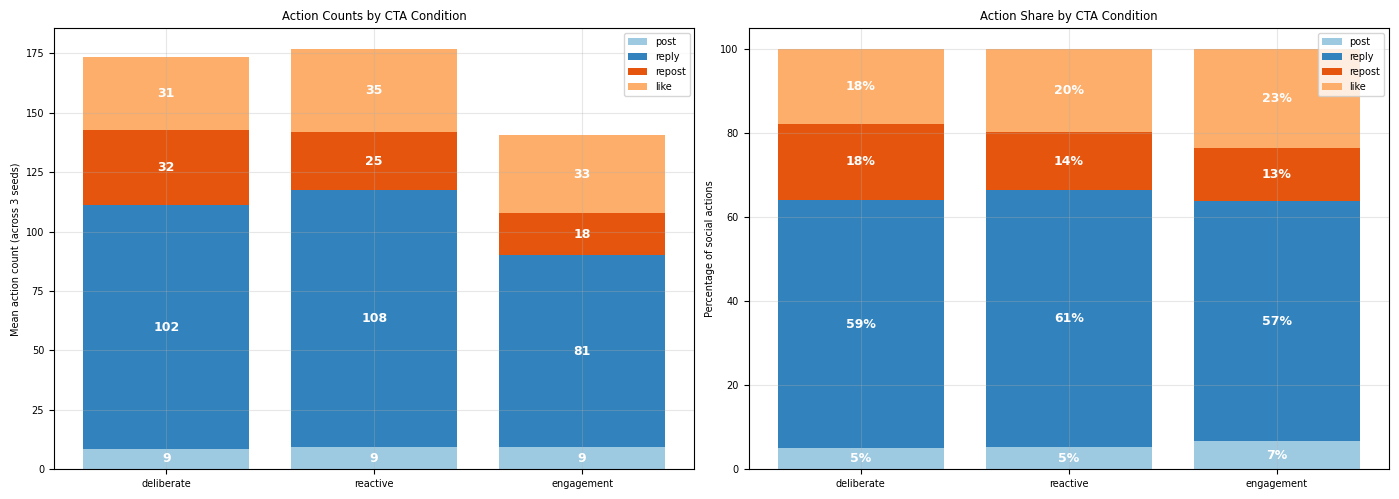

Action       deliberate     reactive   engagement
--------------------------------------------------
post          8.7  (5%)    9.3  (5%)    9.3  (7%)
reply       102.3 (59%)  108.0 (61%)   80.7 (57%)
repost       31.7 (18%)   24.7 (14%)   17.7 (13%)
like         30.7 (18%)   34.7 (20%)   33.0 (23%)
TOTAL             173.3        176.7        140.7


In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: stacked bar of raw counts ---
ax = axes[0]
x = np.arange(len(H4_CONDITIONS))
bottoms = np.zeros(len(H4_CONDITIONS))
act_colors = {'post': '#9ecae1', 'reply': '#3182bd', 'repost': '#e6550d', 'like': '#fdae6b'}

for act in SOCIAL_ACTIONS:
    vals = [np.mean(h4_counts[c][act]) for c in H4_CONDITIONS]
    ax.bar(x, vals, bottom=bottoms, label=act, color=act_colors[act])
    # label inside bar if tall enough
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 4:
            ax.text(xi, b + v/2, f'{v:.0f}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([H4_LABELS[c] for c in H4_CONDITIONS])
ax.set_ylabel('Mean action count (across 3 seeds)')
ax.set_title('Action Counts by CTA Condition')
ax.legend(loc='upper right')

# --- Right: percentage breakdown ---
ax = axes[1]
bottoms = np.zeros(len(H4_CONDITIONS))
for act in SOCIAL_ACTIONS:
    totals = [np.mean(h4_totals[c]) for c in H4_CONDITIONS]
    vals = [np.mean(h4_counts[c][act]) for c in H4_CONDITIONS]
    pcts = [100 * v / t if t > 0 else 0 for v, t in zip(vals, totals)]
    ax.bar(x, pcts, bottom=bottoms, label=act, color=act_colors[act])
    for xi, (p, b) in enumerate(zip(pcts, bottoms)):
        if p > 4:
            ax.text(xi, b + p/2, f'{p:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(pcts)

ax.set_xticks(x)
ax.set_xticklabels([H4_LABELS[c] for c in H4_CONDITIONS])
ax.set_ylabel('Percentage of social actions')
ax.set_title('Action Share by CTA Condition')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('experiments/studies/style_diversity/h4_action_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print(f"{'Action':<10} {'deliberate':>12} {'reactive':>12} {'engagement':>12}")
print('-' * 50)
for act in SOCIAL_ACTIONS:
    row = [np.mean(h4_counts[c][act]) for c in H4_CONDITIONS]
    tots = [np.mean(h4_totals[c]) for c in H4_CONDITIONS]
    pcts = [f'({100*r/t:.0f}%)' for r, t in zip(row, tots)]
    print(f"{act:<10} {row[0]:>6.1f}{pcts[0]:>6} {row[1]:>6.1f}{pcts[1]:>6} {row[2]:>6.1f}{pcts[2]:>6}")
print(f"{'TOTAL':<10} {np.mean(h4_totals['cta=deliberate']):>12.1f} "
      f"{np.mean(h4_totals['cta=reactive']):>12.1f} {np.mean(h4_totals['cta=engagement']):>12.1f}")


### H4 Per-Seed Variability

Each dot is one seed run. Diamonds show means ± 1 std.


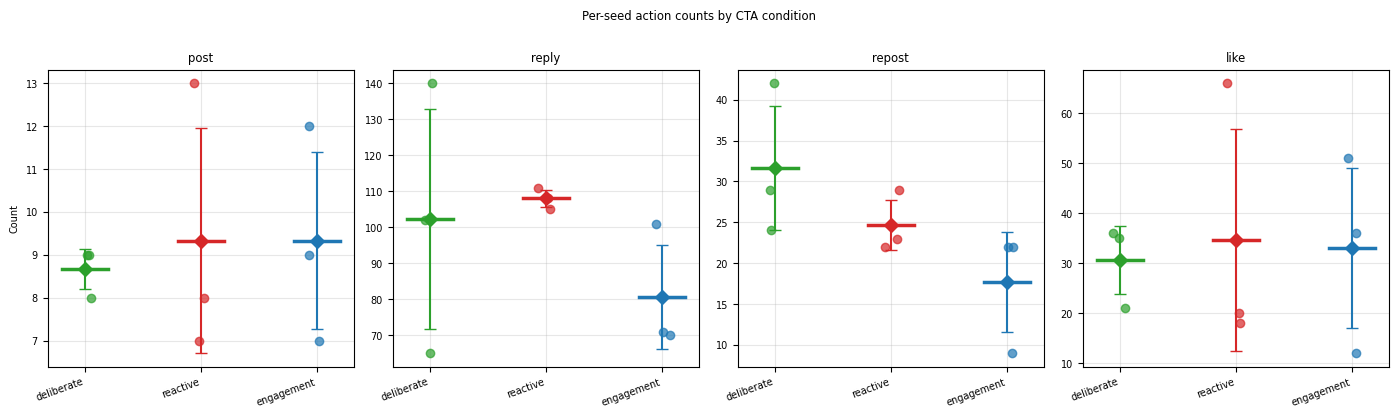

In [22]:
fig, axes = plt.subplots(1, len(SOCIAL_ACTIONS), figsize=(14, 4), sharey=False)

for ai, act in enumerate(SOCIAL_ACTIONS):
    ax = axes[ai]
    for ci, cond in enumerate(H4_CONDITIONS):
        vals = h4_counts[cond][act]
        mean, std = np.mean(vals), np.std(vals)
        # jitter
        jitter = (np.random.rand(len(vals)) - 0.5) * 0.15
        ax.scatter([ci + j for j in jitter], vals, color=H4_COLORS[cond], alpha=0.7, zorder=3)
        ax.plot([ci-0.2, ci+0.2], [mean, mean], color=H4_COLORS[cond], lw=2.5, zorder=4)
        ax.errorbar(ci, mean, yerr=std, fmt='D', color=H4_COLORS[cond], ms=7, capsize=4, zorder=5)
    ax.set_xticks(range(len(H4_CONDITIONS)))
    ax.set_xticklabels([H4_LABELS[c] for c in H4_CONDITIONS], rotation=20, ha='right')
    ax.set_title(act)
    ax.set_ylabel('Count' if ai == 0 else '')

plt.suptitle('Per-seed action counts by CTA condition', y=1.02)
plt.tight_layout()
plt.savefig('experiments/studies/style_diversity/h4_variability.png', dpi=150, bbox_inches='tight')
plt.show()


### H4 Interpretation

| | Prediction | Observed |
|--|--|--|
| `reactive` → highest repost | ✗ | Deliberate highest (18%), reactive 14% |
| `engagement` → most original posts | ✗ | No condition shows elevated posting |
| `deliberate` → most persona-faithful | ? | Highest repost, lowest like — more deliberate choice-making |
| Total activity | — | Engagement lowest (141 vs ~175); framing affects engagement level |

**Reply dominance (~60%) is robust across all conditions** — the misinformation scenario topology
(tight 6-agent network with rich seed posts) pushes agents toward engagement regardless of CTA framing.

The CTA prompt influences *which* non-reply action is chosen, not whether agents engage at all.
Deliberate framing selects for reposts (explicit content endorsement); reactive framing selects for
likes (lower-effort impulsive validation); engagement framing paradoxically suppresses activity
(agents may over-think reach optimization and default to FINISHED).


## Takeaways

### Key Findings

- **Self-BLEU drops 10x** (0.33 to 0.04): gpt4o agents almost never repeat themselves, while gpt4o-mini agents recycle phrases heavily.
- **Lexical diversity nearly doubles** (0.29 to 0.49): gpt4o uses a much richer vocabulary.
- **Opener variety doubles** (0.48 to 0.95): gpt4o-mini opens posts with a handful of stock phrases; gpt4o is nearly unique every time.
- **Content evolution jumps 2x** (0.27 to 0.61): gpt4o agents develop their arguments over time rather than repeating the same points.
- **Action repertoire unlocked**: gpt4o produces original posts and boosts, while gpt4o-mini is locked into reply-only mode (100% replies).
- **Effect is consistent across scenarios**: both ai_conference and misinformation show the same pattern, suggesting the effect is model-driven, not scenario-driven.
- **Per-agent variance tightens**: gpt4o doesn't just shift the mean -- ALL agents improve, reducing the gap between most and least diverse agents.
- **Inter-agent distinctiveness is the exception**: gpt4o-mini scores higher here, likely because each agent fixates on *different* repetitive patterns.

### Limitations

- **n=4 runs per condition** (1 unseeded + 3 seeded): results are averaged across runs, but seeds only vary which agents are active each step and their ordering — LLM stochasticity is the dominant uncontrolled source of variation. True statistical significance testing would require more replications or OpenAI seed pinning.
- **Two scenarios only**: broader generalization requires more scenario types.
- **Cost confound**: gpt4o is ~10x more expensive per token; the diversity gains must be weighed against inference cost.
- **No temperature variation**: all runs use default temperature; higher temperature on mini might partially close the gap.

### Next Steps

- Test intermediate models (gpt4o-mini with higher temperature, or a mid-tier model) to map the capacity-diversity curve.
- Run the misinformation scenario with gpt4o to see if it also produces original posts (currently 0 originals in both models for misinformation).
- Add human evaluation of post quality to complement automated diversity metrics.